In [13]:
#Librerías necesarias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [3]:
#Importación base de datos y convertir a df

df=pd.read_json('https://www.datos.gov.co/resource/d7zw-hpf4.json?$limit=1000000&')

In [4]:
#Visión preliminar del dataset
df.head(10)

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad
0,1996-01-01T00:00:00.000,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1
1,1996-01-01T00:00:00.000,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1
2,1996-01-02T00:00:00.000,5,ANTIOQUIA,5038,ANGOSTURA,SECUESTRO EXTORSIVO,1
3,1996-01-02T00:00:00.000,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1
4,1996-01-02T00:00:00.000,5,ANTIOQUIA,5088,BELLO,SECUESTRO EXTORSIVO,1
5,1996-01-02T00:00:00.000,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1
6,1996-01-03T00:00:00.000,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1
7,1996-01-04T00:00:00.000,63,QUINDIO,63001,ARMENIA,SECUESTRO EXTORSIVO,1
8,1996-01-04T00:00:00.000,18,CAQUETA,18592,PUERTO RICO,SECUESTRO EXTORSIVO,1
9,1996-01-04T00:00:00.000,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO EXTORSIVO,1


In [5]:
#Vista de la estructura general del df cantidad de registros, tipo de columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28020 entries, 0 to 28019
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fecha_hecho   28020 non-null  object
 1   cod_depto     28020 non-null  int64 
 2   departamento  28020 non-null  object
 3   cod_muni      28020 non-null  int64 
 4   municipio     28020 non-null  object
 5   tipo_delito   28020 non-null  object
 6   cantidad      28020 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 1.5+ MB


In [6]:
#Revisión de unicos por departamento
departamentos = df['departamento'].unique()
print(f"Hay {len(departamentos)} departamentos unicos")

Hay 33 departamentos unicos


In [7]:
#Revisión de unicos por municipio
municipios = df['municipio'].unique()
print(f"Hay {len(municipios)} municipios únicos")

Hay 909 municipios únicos


In [8]:
#Convertir fecha_hecho a tipo datetime
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'])
#Crear columnas mes/año
df['mes_ano'] = df['fecha_hecho'].dt.to_period('M').astype(str)

In [16]:
#Crear un df agrupado para crear grafico de tendencia
df_agrupado = df.groupby('mes_ano')['cantidad'].sum().reset_index()
df_agrupado['mes_ano'] = pd.to_datetime(df_agrupado['mes_ano'])

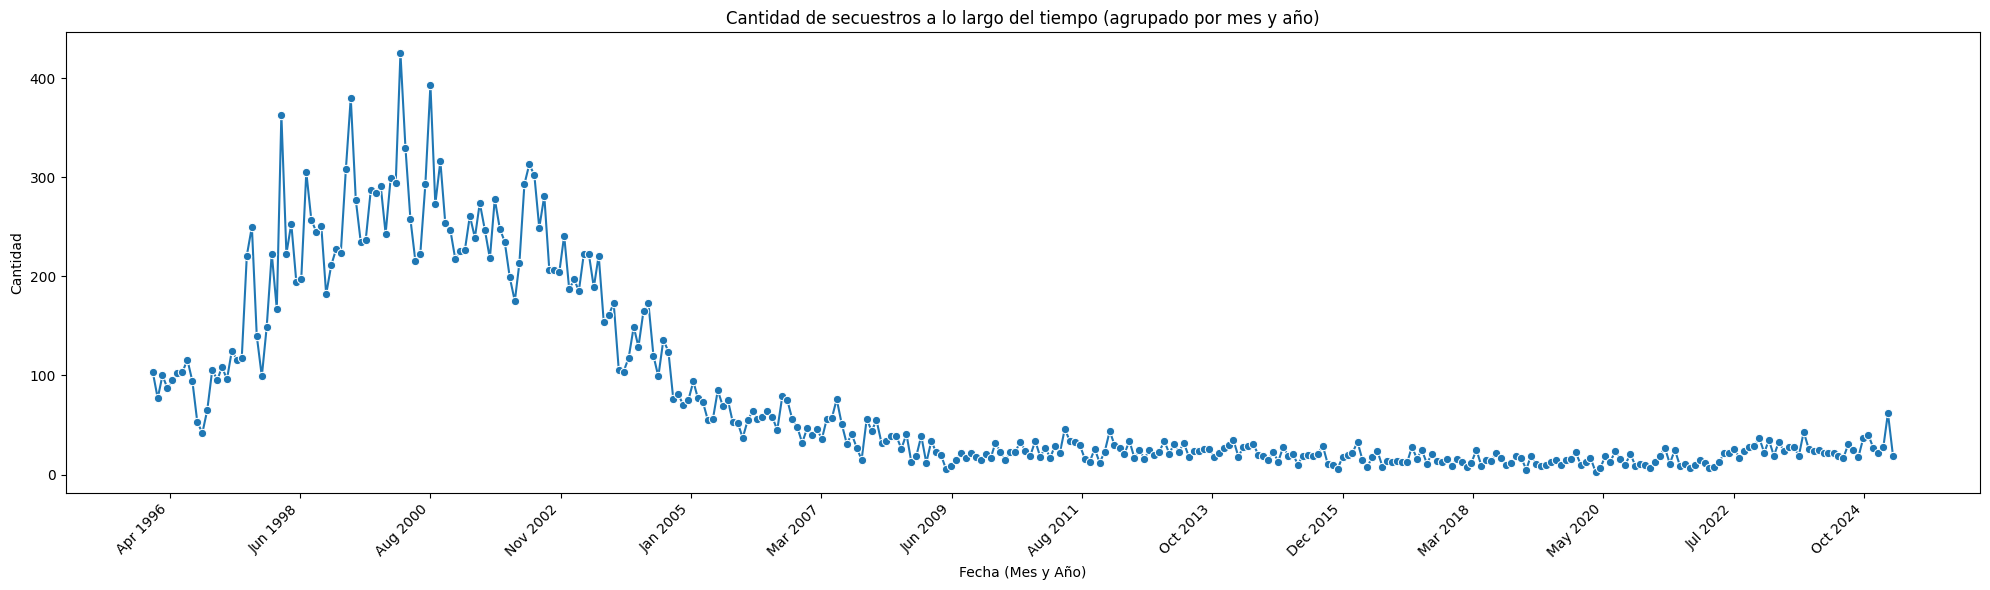

In [22]:
#Codigo para crear grafico

plt.figure(figsize=(20, 6))
sns.lineplot(x='mes_ano', y='cantidad', data=df_agrupado, marker='o')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(15)) #Mostrar cierta cantidad de etiquetas
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.xlabel('Fecha (Mes y Año)')
plt.ylabel('Cantidad')
plt.title('Cantidad de secuestros a lo largo del tiempo (agrupado por mes y año)')
plt.tight_layout()
plt.show()

Se puede ver en la gráfica que los secuestros en Colombia tuvierón su punto máximo sobre comienzos del año 2000 teniendo picos altos también a finales de los años 90's. Desde finales del año 2002 se puede ver una tendencia a la baja en la cantidad de secuestros en Colombia

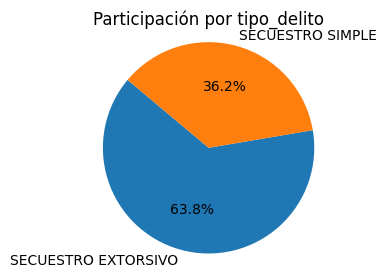

In [25]:
# Calcular la participación de cada tipo_delito
participacion = df['tipo_delito'].value_counts(normalize=True) * 100 #Normalize true, devuelve la proporción del conteo de cada categoría sobre el total

#Crear df para participación
participacion_df = participacion.reset_index()
participacion_df.columns = ['tipo_delito', 'porcentaje']

# Gráfica de torta
plt.figure(figsize=(3, 3))
plt.pie(participacion_df['porcentaje'], labels=participacion_df['tipo_delito'], autopct='%1.1f%%', startangle=140)
plt.title('Participación por tipo_delito')
plt.axis('equal')
plt.show()

In [27]:
# Extrae el año de la fecha y crea una columna con la variable año
df['anio'] = df['fecha_hecho'].dt.year

Para los datos disponibles, vemos que casi el $64$% de los secuestros han sido de indole extorsivo, esto puede deberse a la lucha de guerrillas y la gran cantidad de grupos al margen de la ley que han operado y que en la actualidad siguen delinquiendo en Colombia 

In [ ]:
# Crear tabla pivote: filas son años, columnas son tipo_delito
pivot_table = df.groupby(['anio', 'tipo_delito']).size().unstack(fill_value=0)

# Agrega columna con el total anual
pivot_table['Total'] = pivot_table.sum(axis=1)

# Ordena por el total descendente
pivot_table = pivot_table.sort_values(by='Total', ascending=False)

# Opcional: reinicia el índice para que 'anio' sea columna normal
pivot_table.reset_index(inplace=True)

# Muestra la tabla de forma bonita en Jupyter Notebook
display(pivot_table)


AttributeError: The '.style' accessor requires jinja2